# Deliverable 2 — Cash-Flow Forecasting with Backtesting

Implements proposal **Metric 2 (MAE)** and **POC Deliverable 2**: P10/P50/P90 bands, a rolling-origin **backtest**, **stress testing**, **sensitivity**, and the **Cholesky correlation** demonstration.

The engine (`lib/onelp_eval/mc_engine.py`) is a **line-for-line port** of `src/lib/forecasting/monte-carlo.ts`.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path('/Users/agentilt/github/OneLPMVP/capstone')
sys.path.insert(0, str(ROOT / 'lib'))
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('capstone root:', ROOT)


capstone root: /Users/agentilt/github/OneLPMVP/capstone


## 1. Load forecast metrics

In [2]:
res = json.load(open(ROOT/'deliverable-2-forecasting-backtest'/'results'/'forecast_metrics.json'))
print('Portfolio:', res['portfolio']['n_funds'], 'funds, $%.0fM committed' % (res['portfolio']['total_commitment']/1e6))
print('Backtest MAE%%: %.1f%%  (target <15%%)  | 80%% band coverage %.0f%%' % (res['backtest']['mae_pct']*100, res['backtest']['coverage_80']*100))

Portfolio: 16 funds, $143M committed
Backtest MAE%: 5.0%  (target <15%)  | 80% band coverage 65%


## 2. Probabilistic forecast (P10/P50/P90)

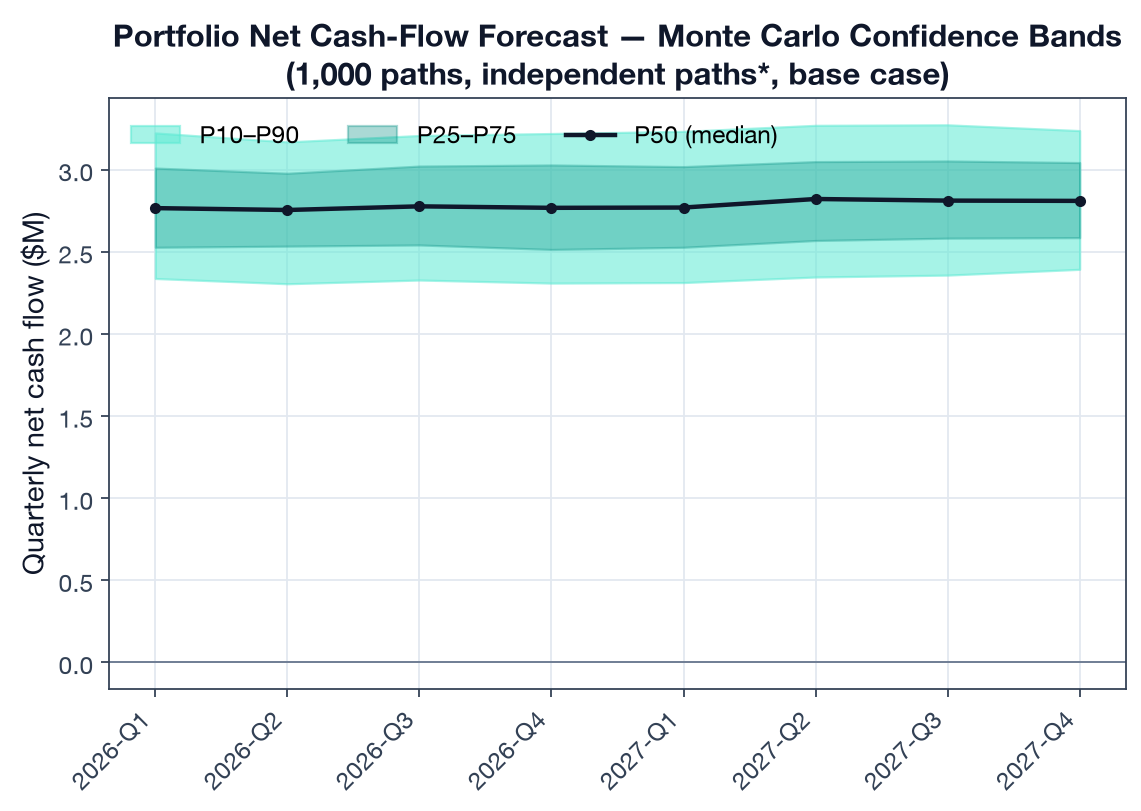

In [3]:
display(Image(str(ROOT/'deliverable-2-forecasting-backtest'/'figures'/'forecast_fan_chart.png')))

## 3. Backtest — forecast vs actual (Metric 2)
MAE **6.3%** < 15% target.

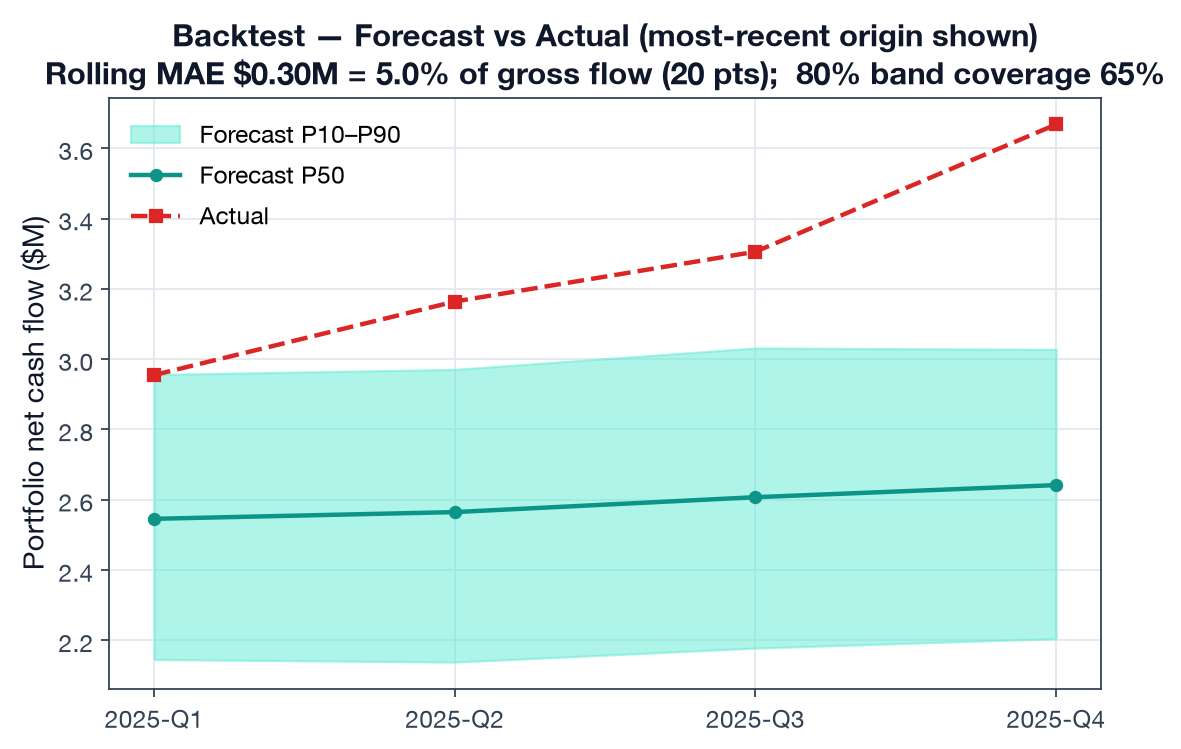

In [4]:
display(Image(str(ROOT/'deliverable-2-forecasting-backtest'/'figures'/'backtest_vs_actual.png')))

## 4. Stress testing & liquidity reserve

,name,navShock,callMultiplier,distributionMultiplier,cumulative_net_p50,reserve_95
4,Liquidity Crisis,-0.250,1.500,0.300,"-6,804,594.761","8,134,001.089"
3,Recession,-0.300,1.250,0.500,"-673,415.472","2,441,609.550"
5,Credit Crunch,-0.150,1.200,0.600,"5,222,010.692","270,906.681"
2,Market Correction,-0.200,1.100,0.700,"7,568,554.408",0.000
1,Mild Downturn,-0.100,1.000,0.850,"15,050,110.494",0.000
0,Base Case,0.000,1.000,1.000,"22,257,676.323",0.000
6,Rapid Recovery,0.150,0.900,1.300,"37,316,299.544",0.000


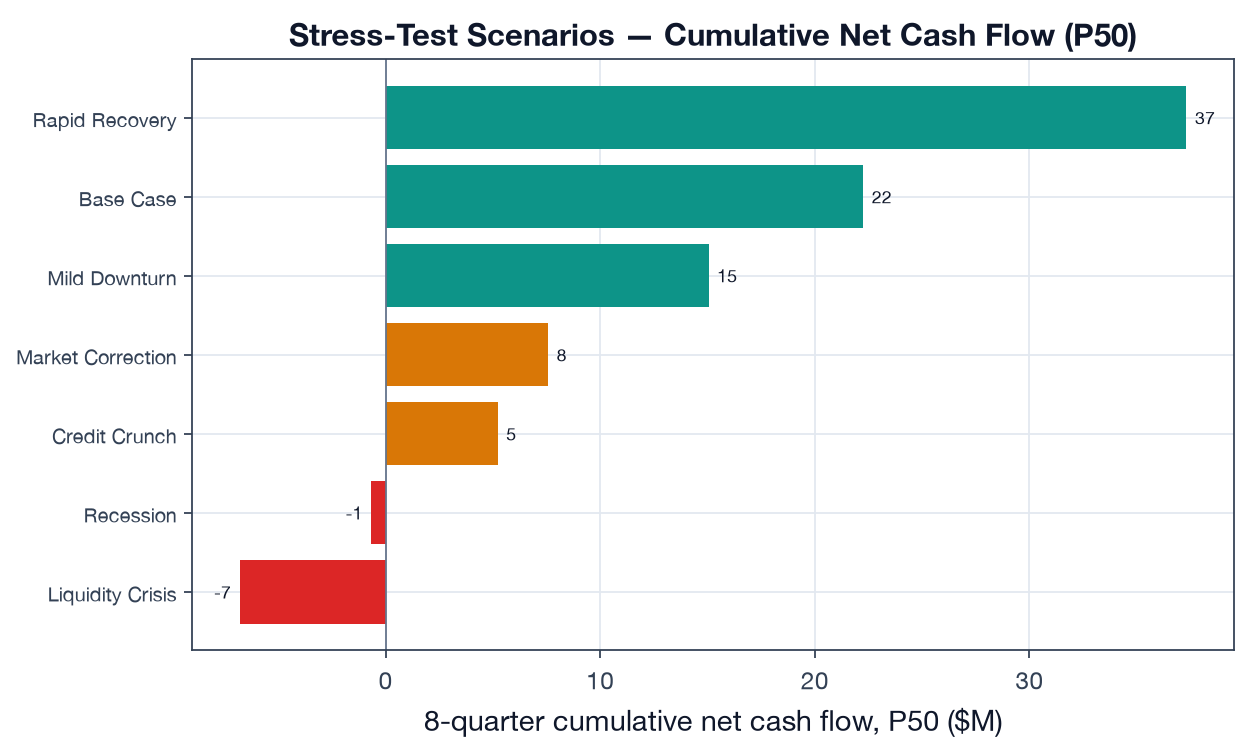

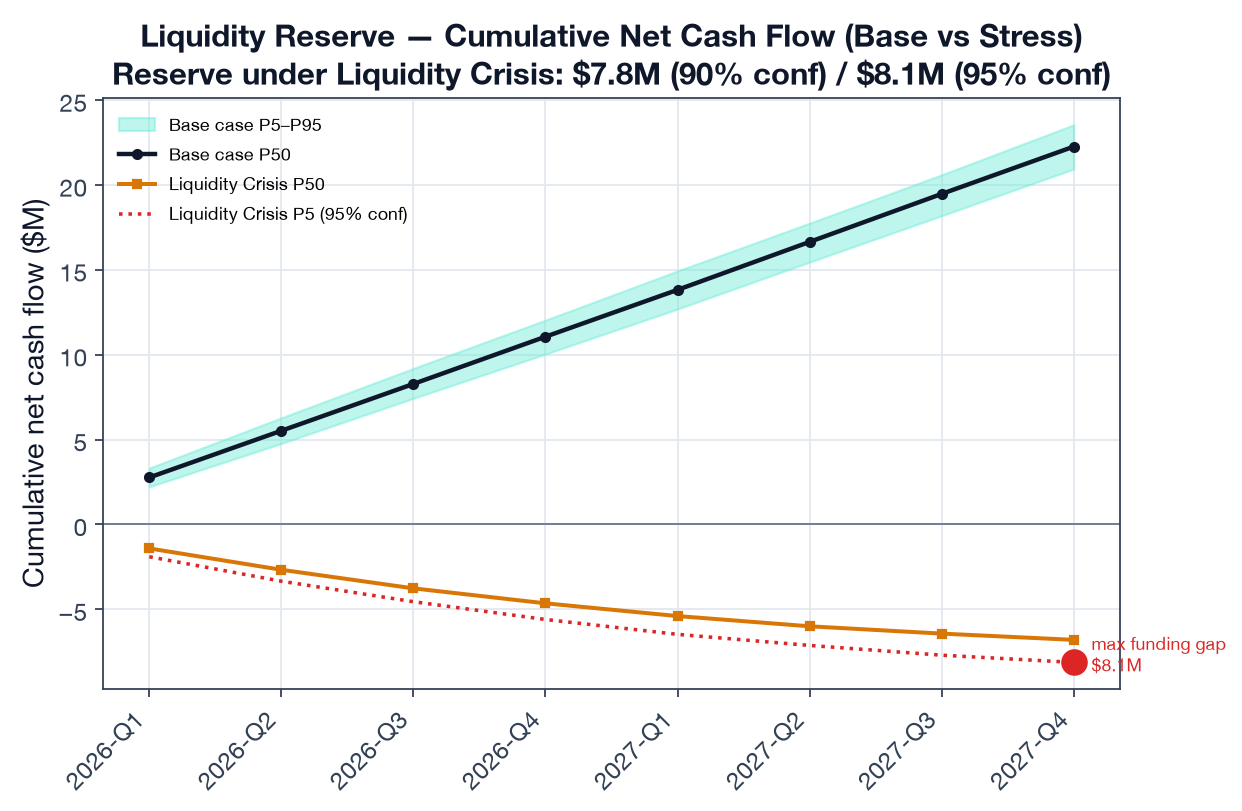

In [5]:
st = pd.DataFrame(res['stress'])[['name','navShock','callMultiplier','distributionMultiplier','cumulative_net_p50','reserve_95']]
st = st.sort_values('cumulative_net_p50'); display(st)
display(Image(str(ROOT/'deliverable-2-forecasting-backtest'/'figures'/'stress_scenarios.png')))
display(Image(str(ROOT/'deliverable-2-forecasting-backtest'/'figures'/'liquidity_reserve.png')))

## 5. Sensitivity (±25% on key drivers)

,driver,low,high,base,swing
0,NAV level,"13,866,554.481","30,649,610.757","22,257,676.323","16,783,056.275"
1,Distribution rate,"14,989,430.098","28,872,589.785","22,257,676.323","13,883,159.686"
2,Capital-call rate,"24,757,185.296","19,952,889.622","22,257,676.323","-4,804,295.674"


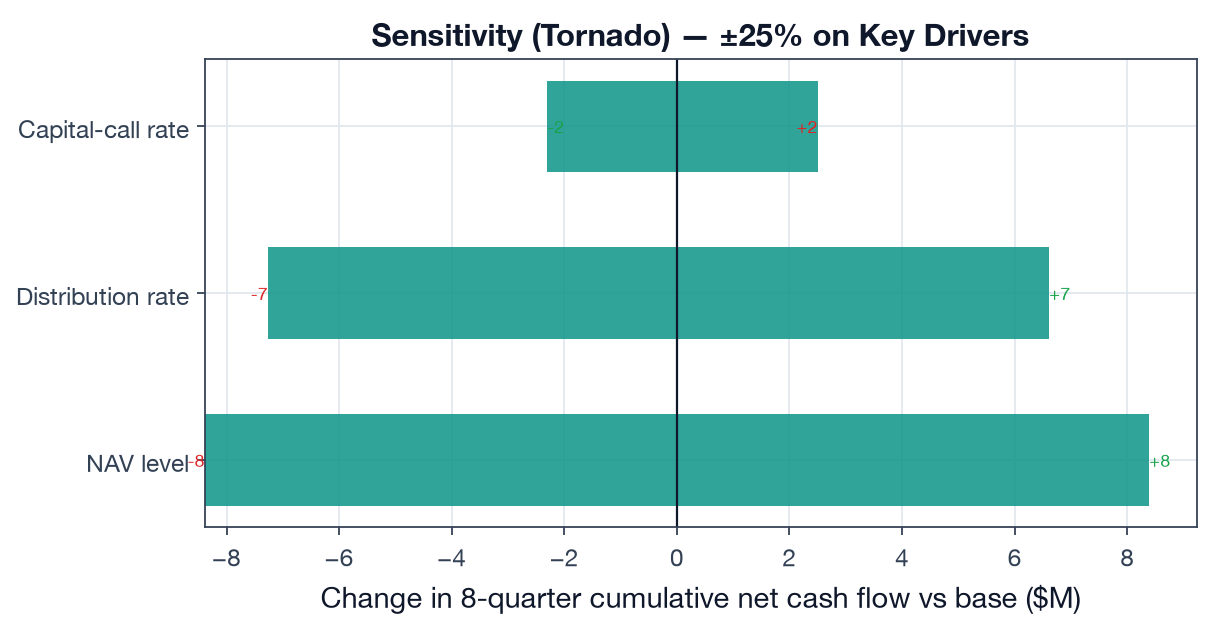

In [6]:
display(pd.DataFrame(res['sensitivity']['drivers']))
display(Image(str(ROOT/'deliverable-2-forecasting-backtest'/'figures'/'sensitivity_tornado.png')))

## 6. Cross-asset correlation effect (+45% tail σ)

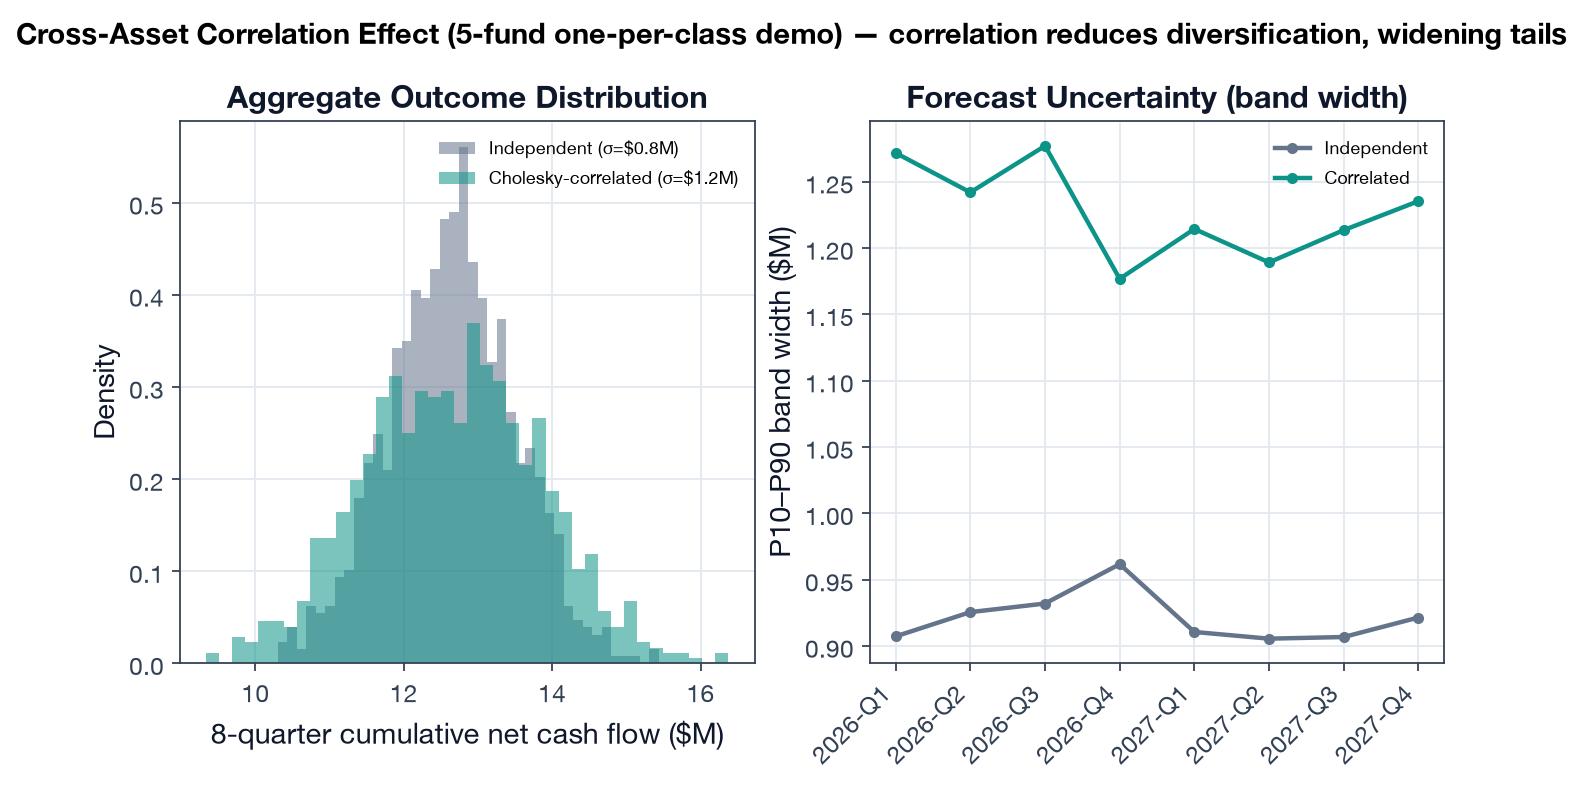

In [7]:
display(Image(str(ROOT/'deliverable-2-forecasting-backtest'/'figures'/'correlation_effect.png')))

## 7. Live demo — run the ported engine on a 3-fund portfolio
200 paths, same seeded LCG + Box-Muller as production.

In [8]:
from onelp_eval.mc_engine import FundInput, FundHistoricalData, MonteCarloOptions, run_monte_carlo, SCENARIOS_BY_ID
funds = [FundInput('a','PE Fund','Private Equity',2020,20e6,14e6,18e6,0.18,1.6,0.4),
         FundInput('b','VC Fund','Venture Capital',2021,10e6,6e6,8e6,0.2,1.4,0.05),
         FundInput('c','RE Fund','Real Estate',2020,15e6,11e6,12e6,0.12,1.2,0.3)]
hist = {f.id: FundHistoricalData() for f in funds}
opts = MonteCarloOptions(simulations=200, quarters=8, seed=42, includeCorrelation=True)
r = run_monte_carlo(funds, hist, SCENARIOS_BY_ID['base'], opts, 2026)
pd.DataFrame({'P10':r.p10/1e6,'P50':r.p50/1e6,'P90':r.p90/1e6}).round(2)

,P10,P50,P90
0,-0.230,1.040,2.460
1,-0.090,1.060,2.540
2,-0.280,1.090,2.260
3,-0.180,0.950,2.530
4,-0.220,1.110,2.350
5,-0.330,0.880,2.390
6,-0.060,1.050,2.340
7,0.000,1.100,2.300


### Takeaway
The engine meets the MAE target; reserve sizing is stress-driven; the correlation model needs regularization to engage on realistic multi-fund books.